# Configuración básica (no tocar)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [6]:
x = Variable()

# Implementación de métodos

In [3]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    # f'(a) y f'(b) deben tener signos opuestos para garantizar que hay un cero entre ellos
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("f'(a) y f'(b) deben tener signos opuestos.")
    for step in range(1, max_iter + 1):
        mid = (a + b) / 2  # punto medio del intervalo
        df_mid = df.eval(mid)
        # se alcanzó la precisión deseada: f' ≈ 0 o el intervalo es suficientemente pequeño
        if abs(df_mid) < tol or (b - a) / 2 < tol:
            return mid, step
        # se achica el intervalo según el signo de f' en el punto medio
        if df.eval(a) * df_mid < 0:
            b = mid
        else:
            a = mid
    # se alcanzó el máximo de iteraciones sin converger
    return (a + b) / 2, max_iter

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()   # calcula f'
    d2f = df.derivative()  # calcula f''
    xn  = x0
    for step in range(1, max_iter + 1):
        df_val  = df.eval(xn)
        d2f_val = d2f.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(df_val) < tol:
            return xn, step
        # si f'' ≈ 0 no se puede dividir, el método no puede continuar
        if abs(d2f_val) < 1e-12:
            raise ValueError(f"f''({xn}) ≈ 0: Newton no puede continuar.")
        xn = xn - df_val / d2f_val  # actualización: x = x - f'(x)/f''(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    xn = x0
    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(grad) < tol:
            return xn, step
        xn = xn - lr * grad  # actualización: x = x - lr * f'(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

### Prueba de métodos

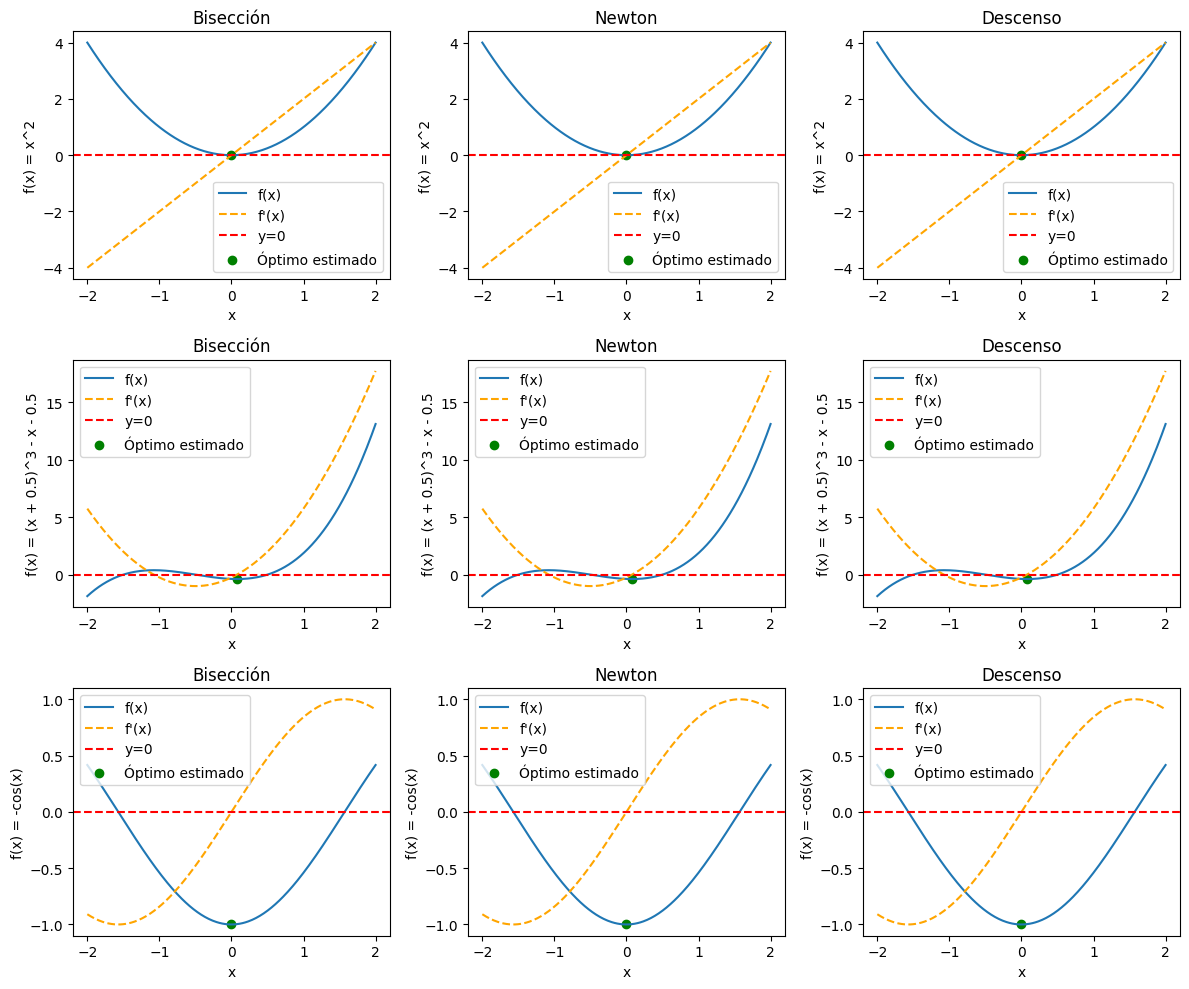

In [4]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.savefig("graficas/seccion2_verificacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Aplicación a función no trivial

In [ ]:
f = x**2 + 2*sin(3*x)

In [ ]:
# Grafica de la función

In [ ]:
# Evaluación de métodos y generación de tablas

# Ajuste de datos

In [7]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [8]:
# Genere la función de pérdida
def funcion_perdida(x_data, y_data, modelo):
    N = len(x_data)

    L = 0
    for xi, yi in zip(x_data, y_data):
        y_hat = modelo(xi)
        L = L + (y_hat - yi)**2

    return L / N

In [10]:
# Optimice la función de pérdida

def descenso_gradiente(f, x0, lr, tol=0.000001, max_iter=1000):
    x = x0
    df = f.derivative()

    for i in range(max_iter):
        grad = df.eval(x)

        if abs(grad) < tol:
            return x, i

        x = x - lr * grad

    return x, max_iter

modelos = {
    "Lineal": {
        "data": df_linear,
        "modelo": lambda xi: w * xi,
        "x0": 0,
        "lr": 0.01,
        "rango_w": np.linspace(-1, 5, 300)
    },
    "Exponencial": {
        "data": df_exp,
        "modelo": lambda xi: exp(w * xi),
        "x0": 0,
        "lr": 0.001,
        "rango_w": np.linspace(-0.5, 0.8, 300)
    },
    "Senoidal": {
        "data": df_sin,
        "modelo": lambda xi: sin(w * xi),
        "x0": 1,
        "lr": 0.01,
        "rango_w": np.linspace(-3, 3, 500)
    }
}

resultados = {}

for nombre, info in modelos.items():
    x_data = info["data"]["x"].values
    y_data = info["data"]["y"].values

    L = funcion_perdida(x_data, y_data, info["modelo"])

    w_optimo, pasos = descenso_gradiente(
        L,
        x0=info["x0"],
        lr=info["lr"],
        max_iter=3000
    )

    resultados[nombre] = {
        "L": L,
        "w_optimo": w_optimo,
        "pasos": pasos,
        "x_data": x_data,
        "y_data": y_data,
        "modelo": info["modelo"],
        "rango_w": info["rango_w"]
    }

    print(nombre)
    print("w óptimo:", w_optimo)
    print("pasos:", pasos)
    print()

Lineal
w óptimo: 1.8479936212016526
pasos: 17

Exponencial
w óptimo: 0.21257607800858003
pasos: 16

Senoidal
w óptimo: 0.6897658763934092
pasos: 61



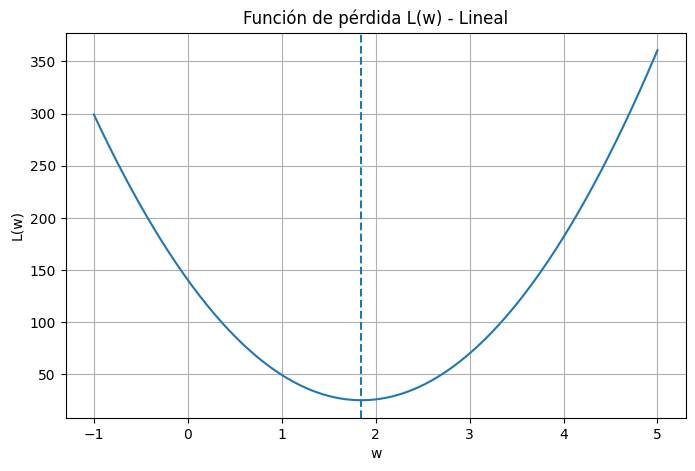

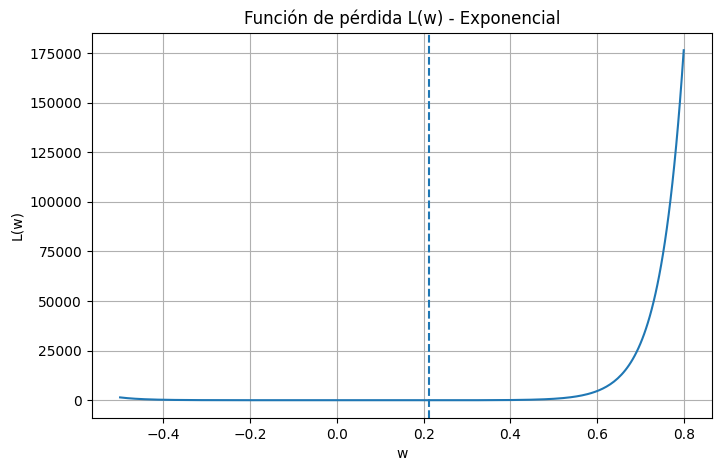

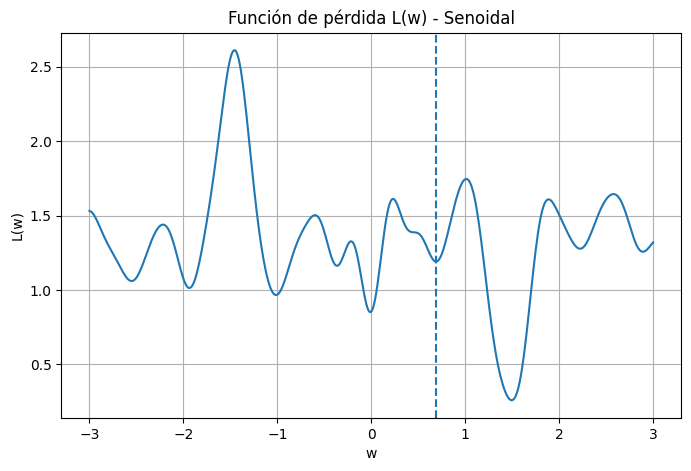

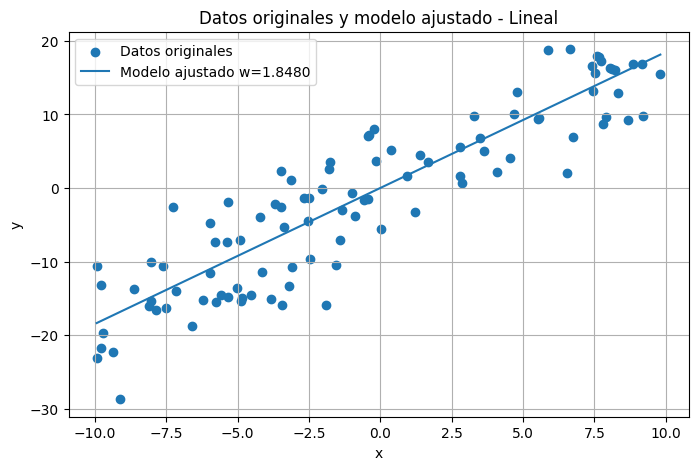

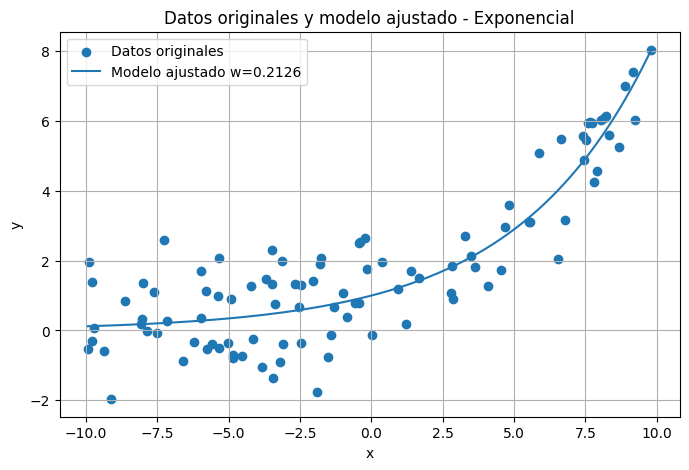

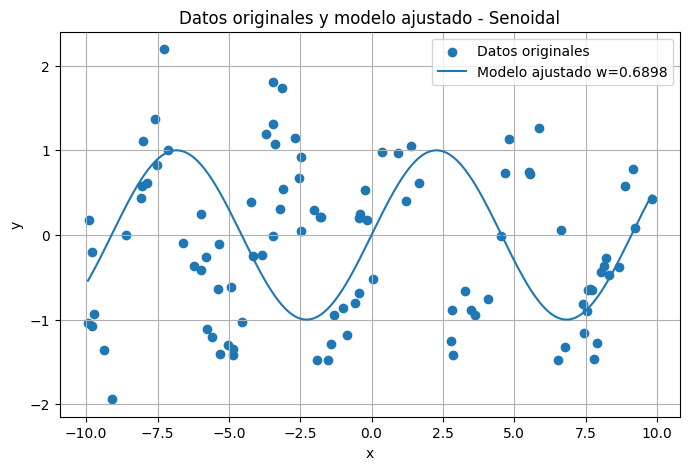

In [11]:
# Grafique datos y ajuste
for nombre, res in resultados.items():
    W = res["rango_w"]
    L = res["L"]

    plt.figure(figsize=(8, 5))
    plt.plot(W, [L.eval(valor) for valor in W])
    plt.axvline(res["w_optimo"], linestyle="--")
    plt.title(f"Función de pérdida L(w) - {nombre}")
    plt.xlabel("w")
    plt.ylabel("L(w)")
    plt.grid(True)
    plt.show()

for nombre, res in resultados.items():
    x_data = res["x_data"]
    y_data = res["y_data"]
    w_optimo = res["w_optimo"]

    x_plot = np.linspace(min(x_data), max(x_data), 300)

    y_plot = []
    for xi in x_plot:
        y_plot.append(res["modelo"](xi).eval(w_optimo))

    plt.figure(figsize=(8, 5))
    plt.scatter(x_data, y_data, label="Datos originales")
    plt.plot(x_plot, y_plot, label=f"Modelo ajustado w={w_optimo:.4f}")
    plt.title(f"Datos originales y modelo ajustado - {nombre}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()    

# BONUS: